# Requirement 3 — Best-of-Both-Worlds Bidding with a Primal-Dual Method

**Task (from `project.pdf`).** Design a bidding strategy for *multiple campaigns* under a budget constraint using a **primal-dual method**. The strategy must work well both in the *stochastic* environment of Requirement 2 and in a *highly non-stationary* environment (a non-stochastic sequence of highest competing bids, e.g. sampled from distributions that change quickly over time). For this requirement we are allowed **full feedback**: after each round we observe the highest competing bid $m_{t,i}$ of *every* campaign $i$.

**What we build in this notebook**

1. Two multi-campaign environments: stochastic (as in Requirement 2) and highly non-stationary (piecewise-constant distributions that change abruptly every segment).
2. A primal-dual agent:
   - **primal** regret maximizer: Hedge over super-arms $(S, b_S)$,
   - **dual** regret minimizer: online gradient descent (OGD) on the Lagrange multiplier $\lambda \in [0, 1/\rho]$, where $\rho = B/T$.
3. Baselines: the LP clairvoyant $OPT_S$ (stochastic environment) and the in-hindsight LP $OPT_A$ with benchmark $\rho\,OPT_A$ (adversarial / non-stationary environment).
4. A comparison with the Combinatorial-UCB agent of Requirement 2, giving the "four curves, two environments" cross-table.

This follows Lecture 8 (*Learning in non-truthful auctions with budget constraints*) and Practical Session 08 (*Constrained problems*).

## Setting and action space

At each round $t \in [T]$:

1. We choose a bid $b_{t,i}$ for each campaign $i$ (or opt out of some campaigns).
2. The competitors realize the highest competing bid $m_{t,i}$ for each campaign.
3. We win campaign $i$ iff $b_{t,i} \ge m_{t,i}$; then we get utility $v_i - b_{t,i}$ and pay cost $b_{t,i}$.
4. We observe the set of won auctions; **in this requirement we also observe all $m_{t,i}$ (full feedback)**.

Because of the conflict graph, the set of campaigns we bid on in a round must be an **independent set** of the graph. Therefore, as in Requirement 2, the natural *action* is a **super-arm**:

$$
a = (S, b_S), \qquad S \in \mathcal{I}(G), \quad b_S \in \mathcal{B}^{|S|},
$$

where $\mathcal{I}(G)$ is the set of independent sets and $\mathcal{B}$ is the discrete bid set. The empty super-arm $(\emptyset, \emptyset)$ means "bid on nothing" and is always feasible.

For a super-arm $a$ its realized round-utility and round-cost are

$$
f_t(a) = \sum_{i \in S} (v_i - b_i)\,\mathbb{1}\{b_i \ge m_{t,i}\},
\qquad
c_t(a) = \sum_{i \in S} b_i\,\mathbb{1}\{b_i \ge m_{t,i}\}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, product
from scipy import optimize

In [2]:
# ============================================================
# Problem parameters (same spirit as requirement_2.ipynb)
# ============================================================
T = 2000                      # number of rounds
n_campaigns = 3
my_valuations = np.array([0.4, 0.6, 0.8])   # v_i for each campaign
n_competitors = [2, 3, 5]     # competing bidders per campaign

# Discrete bid set (the same grid for every campaign)
available_bids = np.linspace(0, 1, 11)
n_bids = len(available_bids)
bid_to_index = {round(b, 8): i for i, b in enumerate(available_bids)}

# Shared budget: B is chosen so that rho = B/T is *binding*
B = 100
rho = B / T

# Conflict graph: campaigns 2 and 3 (0-indexed: 1 and 2) are non-compatible,
# i.e. they cannot be bid on in the same round.
conflict_edges = [(1, 2)]

# ---------- super-arms: (independent set, bid vector) ----------
def enumerate_independent_sets(n_campaigns, conflict_edges):
    conflicts = set(conflict_edges)

    def is_independent(subset):
        subset = set(subset)
        return not any({i, j} <= subset for i, j in conflicts)

    return [subset
            for size in range(n_campaigns + 1)
            for subset in combinations(range(n_campaigns), size)
            if is_independent(subset)]

def build_super_arms(independent_sets, available_bids, my_valuations, eps=1e-6):
    super_arms = []
    for subset in independent_sets:
        if not subset:
            super_arms.append((subset, ()))          # empty super-arm = opt-out
        else:
            # only "good" bids: b <= v_i (higher bids give negative utility)
            valid_bids = [[b for b in available_bids if b <= my_valuations[i] + eps]
                          for i in subset]
            super_arms.extend((subset, bids) for bids in product(*valid_bids))
    return super_arms

independent_sets = enumerate_independent_sets(n_campaigns, conflict_edges)
super_arms = build_super_arms(independent_sets, available_bids, my_valuations)
K = len(super_arms)
empty_idx = next(k for k, (S, _) in enumerate(super_arms) if len(S) == 0)

print("Independent sets (0-indexed):", independent_sets)
print("Number of super-arms:", K)
print("rho =", rho, " lambda_max =", 1 / rho)

Independent sets (0-indexed): [(), (0,), (1,), (2,), (0, 1), (0, 2)]
Number of super-arms: 102
rho = 0.05  lambda_max = 20.0


## Environments

**Stochastic environment.** As in Requirement 2, each campaign $i$ has $k_i$ competitors whose bids are i.i.d. $\mathrm{Uniform}(0,1)$; hence

$$
m_{t,i} \sim \mathrm{Beta}(k_i, 1), \qquad \mathbb{P}(b \ge m_i) = b^{k_i}.
$$

**Highly non-stationary environment.** The horizon is partitioned into segments; in each segment the *distribution* of the competing bids is fixed, and it changes abruptly from segment to segment ("sampled from a distribution that changes quickly over time"). Concretely, in segment $s$ the competitors of campaign $i$ bid $\mathrm{Uniform}(0, u_{s,i})$, so the distribution (and hence the optimal bid) jumps every $T / \text{n\_segments}$ rounds. The sequence is generated with a fixed seed, so it is a fixed (oblivious-adversarial) sequence across trials.

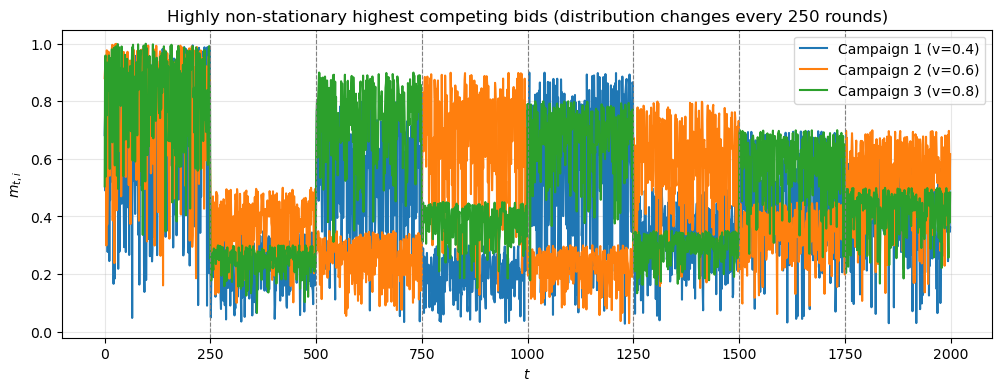

In [3]:
# ============================================================
# Environments
# ============================================================
def stochastic_competing_bids(seed, n_competitors, T):
    """i.i.d. rounds: m_{t,i} = max of k_i Uniform(0,1) ~ Beta(k_i,1)."""
    rng = np.random.default_rng(seed)
    m = np.empty((len(n_competitors), T))
    for i, k in enumerate(n_competitors):
        m[i] = rng.uniform(0, 1, size=(k, T)).max(axis=0)
    return m

# Segment scales for the non-stationary environment (rows = segments).
# In segment s, campaign i's competitors bid Uniform(0, segment_scales[s, i]).
n_segments = 8
segment_scales = np.array([
    [1.00, 1.00, 1.00],
    [0.35, 0.50, 0.30],
    [0.80, 0.35, 0.90],
    [0.30, 0.90, 0.45],
    [0.90, 0.30, 0.80],
    [0.50, 0.80, 0.35],
    [0.70, 0.45, 0.70],
    [0.60, 0.70, 0.50],
])

def nonstationary_competing_bids(seed, n_competitors, T, segment_scales):
    """Fixed (oblivious-adversarial) sequence with abrupt distribution changes."""
    rng = np.random.default_rng(seed)
    n_segments, n_campaigns = segment_scales.shape
    seg_len = T // n_segments
    m = np.empty((n_campaigns, T))
    for s in range(n_segments):
        start, end = s * seg_len, (s + 1) * seg_len
        for i in range(n_campaigns):
            u = segment_scales[s, i]
            m[i, start:end] = rng.uniform(0, u, size=(n_competitors[i], seg_len)).max(axis=0)
    return m

# Visualize the non-stationary sequence
m_ns = nonstationary_competing_bids(seed=123, n_competitors=n_competitors,
                                    T=T, segment_scales=segment_scales)
plt.figure(figsize=(12, 4))
for i in range(n_campaigns):
    plt.plot(m_ns[i], label=f"Campaign {i+1} (v={my_valuations[i]})")
for s in range(1, n_segments):
    plt.axvline(s * (T // n_segments), color="gray", ls="--", lw=0.8)
plt.xlabel("$t$")
plt.ylabel("$m_{t,i}$")
plt.title("Highly non-stationary highest competing bids (distribution changes every 250 rounds)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Understanding the non-stationary environment (as in Lab 10)

In Lab 10 (`10_nonstationary_bandits.ipynb`), a non-stationary environment is described by piecewise-constant mean-reward functions, and the natural benchmark becomes the best *policy* in hindsight rather than the best arm. The analogue here is direct: within each segment the **distribution** of the competing bids is fixed, hence the expected utility of every bid is fixed, and the best bid changes whenever the segment changes.

The figure below shows, for every campaign and segment, the **best expected utility achievable on the bid grid** (top panel) and the **bid that achieves it** (bottom panel). The optimal bid jumps at segment boundaries (e.g., campaign 3 alternates between low bids around 0.3–0.5 in "cheap" segments and high bids around 0.7 in expensive ones). No fixed bid is optimal everywhere: a learner must keep adapting, which is why a full-feedback primal-dual method (re-evaluating all super-arms every round) is a natural fit for this environment.

Best discrete bid per segment (rows = segments, columns = campaigns):
[[0.3 0.4 0.7]
 [0.3 0.4 0.3]
 [0.3 0.4 0.7]
 [0.3 0.4 0.5]
 [0.3 0.3 0.7]
 [0.3 0.4 0.4]
 [0.3 0.4 0.7]
 [0.3 0.4 0.5]]
Number of best-bid changes per campaign: [0, 2, 7]


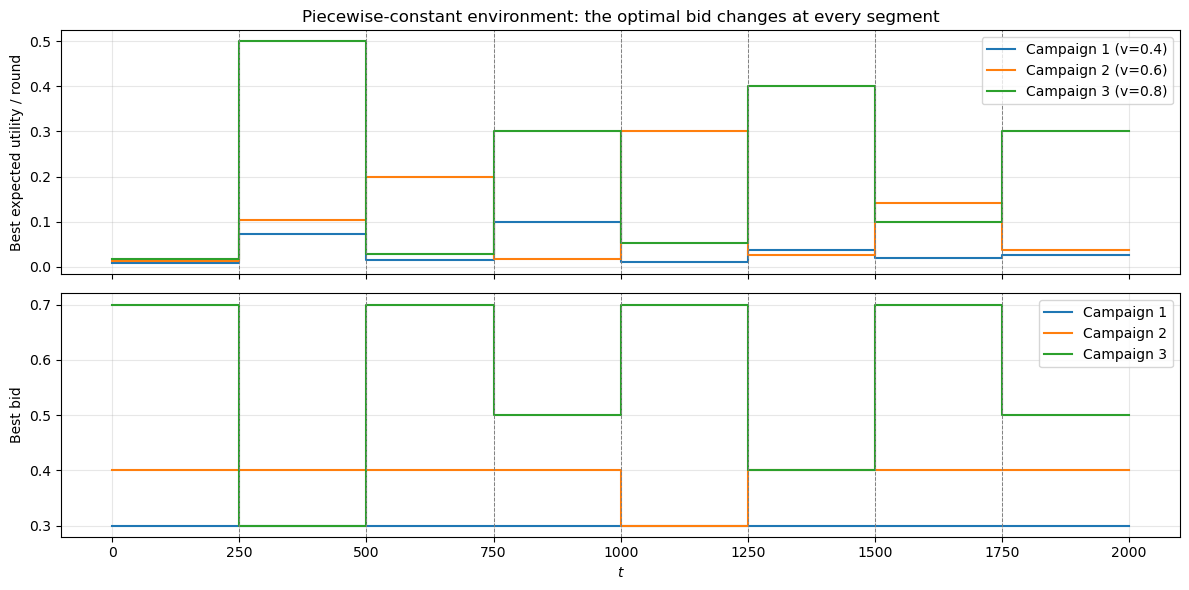

In [4]:
# ============================================================
# Lab-10-style analysis: how the environment (and the optimal
# action) changes over time
# ============================================================
seg_len = T // n_segments
best_bid = np.zeros((n_segments, n_campaigns))
best_util = np.zeros((n_segments, n_campaigns))

for i in range(n_campaigns):
    v = my_valuations[i]
    k = n_competitors[i]
    for s in range(n_segments):
        u = segment_scales[s, i]
        p_win = np.minimum((available_bids / u) ** k, 1.0)     # P(b >= m) in segment s
        util = (v - available_bids) * p_win
        util[available_bids > v + 1e-6] = -np.inf               # dominated bids (b > v)
        j = int(np.argmax(util))
        best_bid[s, i] = available_bids[j]
        best_util[s, i] = util[j]

print("Best discrete bid per segment (rows = segments, columns = campaigns):")
print(np.round(best_bid, 2))
print("Number of best-bid changes per campaign:",
      [int(np.sum(np.diff(best_bid[:, i]) != 0)) for i in range(n_campaigns)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t_seg = np.arange(0, T + 1, seg_len)
for i in range(n_campaigns):
    ax1.step(t_seg, np.append(best_util[:, i], best_util[-1, i]), where='post',
             label=f"Campaign {i+1} (v={my_valuations[i]})")
    ax2.step(t_seg, np.append(best_bid[:, i], best_bid[-1, i]), where='post',
             label=f"Campaign {i+1}")
for s in range(1, n_segments):
    ax1.axvline(s * seg_len, color="gray", ls="--", lw=0.7)
    ax2.axvline(s * seg_len, color="gray", ls="--", lw=0.7)
ax1.set_ylabel("Best expected utility / round")
ax2.set_ylabel("Best bid")
ax2.set_xlabel("$t$")
ax1.set_title("Piecewise-constant environment: the optimal bid changes at every segment")
ax1.legend(); ax2.legend(); ax1.grid(alpha=0.3); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Full feedback: realized utility/cost of every super-arm

Since we observe $m_t = (m_{t,1}, \dots, m_{t,N})$ after round $t$, we can compute $f_t(a)$ and $c_t(a)$ for **every** super-arm $a$. This turns the primal problem into an *adversarial expert problem* (full feedback), for which Hedge is the natural regret minimizer.

In [5]:
# ============================================================
# Full-feedback oracle
# ============================================================
def super_arm_fc(m_t, super_arms, my_valuations, available_bids, bid_to_index):
    """Given the vector m_t (highest competing bid of each campaign), return
    f_t(a) and c_t(a) for EVERY super-arm a."""
    win = available_bids[None, :] >= m_t[:, None]                    # (N, Kb)
    rew = (my_valuations[:, None] - available_bids[None, :]) * win   # (N, Kb)
    cost = available_bids[None, :] * win                             # (N, Kb)

    f_vec = np.zeros(len(super_arms))
    c_vec = np.zeros(len(super_arms))
    for k, (subset, bids) in enumerate(super_arms):
        if not subset:
            continue
        idx = np.array([bid_to_index[round(b, 8)] for b in bids])
        subset_arr = np.array(subset)
        f_vec[k] = rew[subset_arr, idx].sum()
        c_vec[k] = cost[subset_arr, idx].sum()
    return f_vec, c_vec

# Bounds used to normalize the primal rewards of Hedge to [0, 1]
F_max = float(max(sum(my_valuations[list(S)]) for S, _ in super_arms))
C_max = float(max(sum(bids) for _, bids in super_arms))
print("F_max =", F_max, " C_max =", C_max)

F_max = 1.2000000000000002  C_max = 1.2000000000000002


## The primal-dual method

We Lagrangify the budget constraint $\mathbb{E}[c_t] \le \rho$ (with $\rho = B/T$):

$$
L(\gamma, \lambda, f_t, c_t) = \mathbb{E}_{a \sim \gamma}[f_t(a)] - \lambda \left( \mathbb{E}_{a \sim \gamma}[c_t(a)] - \rho \right).
$$

The agent plays a **two-player game**:

- the **primal player** chooses $\gamma \in \Delta(\mathcal{A})$ to *maximize* $L$;
- the **dual player** chooses $\lambda \in [0, 1/\rho]$ to *minimize* $L$.

**Primal regret minimizer — Hedge.** For a fixed $\lambda_t$, maximizing $L$ over super-arms is equivalent to maximizing the per-arm reward

$$
r_t(a) = f_t(a) - \lambda_t\, c_t(a).
$$

We feed Hedge with the losses $1 - \text{normalized}(r_t(a)) \in [0,1]$ (normalized per round using the min/max of the Lagrangian rewards, which is the standard practical way to keep the losses in $[0,1]$ without being killed by loose worst-case bounds); Hedge maintains weights $w_{t+1}(a) = w_t(a)\,e^{-\eta \ell_t(a)}$ and plays $a_t \sim x_t = w_t / \sum w_t$.

**Dual regret minimizer — OGD.** The dual loss is $\ell^D_t(\lambda) = \lambda(\rho - \mathbb{E}_{a\sim x_t}[c_t(a)])$, so one gradient step gives

$$
\lambda_{t+1} = \Pi_{[0,1/\rho]}\Big(\lambda_t + \eta_\lambda \big(\mathbb{E}_{a \sim x_t}[c_t(a)] - \rho_t\big)\Big),
\qquad \rho_t = \frac{\text{remaining budget}}{T - t},
$$

where we use the expected cost under $x_t$ thanks to full feedback, and $\rho_t$ is the *remaining-budget* per-round cap (pacing): if we are under-spending, $\rho_t > \rho$ and the multiplier decreases, making the primal more aggressive; if we overspend, $\rho_t < \rho$ and the multiplier increases, making the primal more conservative. This is the same pacing idea sketched in the team's `draft_solution.ipynb`.

**Hard budget.** If the remaining budget is below the smallest meaningful payment (we use $<1$ as in the course), the agent stops bidding and plays the empty super-arm.

**Why "best of both worlds".** The same algorithm (same hyperparameters) guarantees:

- stochastic environment: regret $\tilde{O}(\sqrt{T})$ w.r.t. the LP clairvoyant $OPT_S$ (Balseiro & Gur 2019; Badanidiyuru et al. 2018);
- adversarial environment: utility at least $\rho\, T\, OPT_A - \tilde{O}(\sqrt{T})$, where $OPT_A$ is the best fixed distribution in hindsight (Castiglioni et al. 2022). No algorithm can guarantee more than a $\rho$ fraction of $OPT_A$ in the worst case.

In [6]:
# ============================================================
# Primal-dual agent (full feedback)
# ============================================================
class PrimalDualAgent:
    """Bidding via primal-dual method.

    Primal (maximizer of the Lagrangian): Hedge over super-arms with
        r_t(a) = f_t(a) - lambda_t * c_t(a).
    Dual (minimizer): online gradient descent on lambda in [0, 1/rho].
    """

    def __init__(self, super_arms, empty_idx, T, B, F_max, C_max):
        self.super_arms = super_arms
        self.empty_idx = empty_idx
        self.K = len(super_arms)
        self.T = T
        self.B = B
        self.rho = B / T
        self.F_max = F_max
        self.C_max = C_max
        self.lambda_max = 1 / self.rho

        self.weights = np.ones(self.K)
        self.x_t = np.ones(self.K) / self.K
        self.lmbd = 1.0

        self.hedge_eta = np.sqrt(np.log(self.K) / self.T)
        self.ogd_eta = 1 / np.sqrt(self.T)

        self.budget = B
        self.t = 0
        self.lmbd_history = []

    def pull_arm(self):
        if self.budget < 1:              # hard budget constraint
            return self.empty_idx
        self.x_t = self.weights / self.weights.sum()
        return np.random.choice(self.K, p=self.x_t)

    def update(self, f_vec, c_vec, a_t):
        # --- primal: Hedge maximizes f(a) - lambda*c(a) ---
        primal_reward = f_vec - self.lmbd * c_vec
        # Practical normalization to [0,1] using the per-round range of the
        # Lagrangian rewards (the worst-case bounds are much looser than the
        # realized rewards, which would make Hedge learn too slowly).
        r_min = primal_reward.min()
        r_max = primal_reward.max()
        span = r_max - r_min
        if span < 1e-12:
            loss = 0.5 * np.ones_like(primal_reward)              # all arms equal
        else:
            normalized = (primal_reward - r_min) / span           # rewards in [0,1]
            loss = 1.0 - normalized                               # losses in [0,1]
        self.weights *= np.exp(-self.hedge_eta * loss)
        self.weights /= self.weights.max()                        # numerical stability

        # --- dual: OGD with remaining-budget pacing ---
        # Instead of the fixed rho, we use rho_t = remaining budget / remaining
        # rounds: if we are under-spending, rho_t > rho and lambda decreases
        # (more aggressive bidding), and vice versa.
        expected_cost = c_vec @ self.x_t
        rho_t = max(self.budget / (self.T - self.t), 1e-9)
        self.lmbd = np.clip(self.lmbd + self.ogd_eta * (expected_cost - rho_t),
                            0.0, self.lambda_max)
        self.lmbd_history.append(self.lmbd)

        # --- hard budget ---
        self.budget -= c_vec[a_t]
        self.t += 1

## Baselines

**Stochastic environment — $OPT_S$.** The clairvoyant knows the true distributions and solves

$$
\max_{\gamma \in \Delta(\mathcal{A})} \sum_a \gamma(a)\, \bar f(a)
\quad \text{s.t.} \quad
\sum_a \gamma(a)\, \bar c(a) \le \rho,
$$

with $\bar f(a) = \sum_{i \in S}(v_i - b_i)\,b_i^{k_i}$ and $\bar c(a) = \sum_{i \in S} b_i\, b_i^{k_i}$. This is a linear program.

**Adversarial / non-stationary environment — $OPT_A$.** The baseline is the *best fixed distribution in hindsight*: the same LP, but with the **empirical** win probabilities computed on the realized sequence $m_1, \dots, m_T$. In the worst case no algorithm can beat $\rho\,OPT_A$, so we plot regret against the per-round benchmark $\rho\,OPT_A$.

In [7]:
# ============================================================
# Baselines (LP clairvoyants)
# ============================================================
def compute_clairvoyant_lp(super_arm_rewards, super_arm_costs, rho):
    """Best fixed distribution over super-arms with expected cost <= rho."""
    res = optimize.linprog(-super_arm_rewards,
                           A_ub=[super_arm_costs], b_ub=[rho],
                           A_eq=[np.ones(len(super_arm_rewards))], b_eq=[1],
                           bounds=(0, 1), method="highs")
    if not res.success:
        raise ValueError(res.message)
    return res.x, -res.fun

def stochastic_clairvoyant(super_arms, my_valuations, n_competitors,
                           available_bids, bid_to_index, rho):
    """OPT_S: LP with the TRUE win probabilities P_i(b) = b^{k_i}."""
    win_prob = np.array([available_bids ** k for k in n_competitors])
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))
    for k, (subset, bids) in enumerate(super_arms):
        if not subset:
            continue
        idx = np.array([bid_to_index[round(b, 8)] for b in bids])
        subset_arr = np.array(subset)
        p = win_prob[subset_arr, idx]
        rewards[k] = ((my_valuations[subset_arr] - np.array(bids)) * p).sum()
        costs[k] = (np.array(bids) * p).sum()
    return compute_clairvoyant_lp(rewards, costs, rho)

def adversarial_clairvoyant(m_seq, super_arms, my_valuations,
                            available_bids, bid_to_index, rho):
    """OPT_A: LP with EMPIRICAL win probabilities over the realized sequence."""
    T = m_seq.shape[1]
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))
    for t in range(T):
        f_vec, c_vec = super_arm_fc(m_seq[:, t], super_arms, my_valuations,
                                    available_bids, bid_to_index)
        rewards += f_vec
        costs += c_vec
    return compute_clairvoyant_lp(rewards / T, costs / T, rho)

gamma_s, OPT_S = stochastic_clairvoyant(super_arms, my_valuations, n_competitors,
                                        available_bids, bid_to_index, rho)
print("OPT_S (per-round expected utility):", OPT_S)

# expected cost of OPT_S (sanity check: should be ~rho when the budget binds)
win_prob_s = np.array([available_bids ** k for k in n_competitors])
costs_s = np.zeros(len(super_arms))
for k, (subset, bids) in enumerate(super_arms):
    if not subset:
        continue
    idx = np.array([bid_to_index[round(b, 8)] for b in bids])
    costs_s[k] = (np.array(bids) * win_prob_s[np.array(subset), idx]).sum()
print("Expected cost of OPT_S:", gamma_s @ costs_s, " rho =", rho)

OPT_S (per-round expected utility): 0.022943465045592713
Expected cost of OPT_S: 0.05  rho = 0.05


## Baseline agent for comparison: Combinatorial-UCB

We also run the Requirement-2-style **Combinatorial-UCB** agent (bandit feedback). It keeps UCBs on utilities and LCBs on costs for every base arm $(i, b)$, scores every super-arm by summing the bounds, and solves the same LP over super-arms. Two small fixes relative to the current R2 notebook:

- the LP is solved **every round** (no shortcut that bypasses it),
- the per-round cap uses the **remaining budget**: $\rho_t = \text{remaining}/(T-t)$, so the algorithm paces its spending.

This gives C-UCB a fair chance in the stochastic environment; on the non-stationary sequence it is expected to degrade because its averages are stale.

In [8]:
# ============================================================
# Combinatorial-UCB agent (Requirement 2 style, bandit feedback)
# ============================================================
class CombinatorialUCBAgent:
    def __init__(self, super_arms, empty_idx, bid_to_index,
                 n_campaigns, n_bids, my_valuations, T, B):
        self.super_arms = super_arms
        self.empty_idx = empty_idx
        self.bid_to_index = bid_to_index
        self.N = n_campaigns
        self.Kb = n_bids
        self.my_valuations = my_valuations
        self.T = T
        self.B = B
        self.rho = B / T

        self.avg_f = np.zeros((n_campaigns, n_bids))
        self.avg_c = np.zeros((n_campaigns, n_bids))
        self.N_pulls = np.zeros((n_campaigns, n_bids))
        self.budget = B
        self.t = 0
        self.large_value = (1 + np.sqrt(2 * np.log(T))) * my_valuations.max()

    def _bounds(self):
        f_ucb = np.zeros((self.N, self.Kb))
        c_lcb = np.zeros((self.N, self.Kb))
        for i in range(self.N):
            n = self.N_pulls[i]
            pulled = n > 0
            radius = np.zeros(self.Kb)
            radius[pulled] = self.my_valuations[i] * np.sqrt(2 * np.log(self.T) / n[pulled])
            f_ucb[i] = self.avg_f[i] + radius
            f_ucb[i, ~pulled] = self.large_value
            c_lcb[i] = np.maximum(self.avg_c[i] - radius, 0.0)   # optimistic on costs
        return f_ucb, c_lcb

    def pull_arm(self):
        if self.budget < 1:
            return self.empty_idx
        rho_t = max(self.budget / (self.T - self.t), 1e-9)   # remaining per-round budget
        f_ucb, c_lcb = self._bounds()

        F = np.zeros(len(self.super_arms))
        C = np.zeros(len(self.super_arms))
        for k, (subset, bids) in enumerate(self.super_arms):
            if not subset:
                continue
            idx = [self.bid_to_index[round(b, 8)] for b in bids]
            F[k] = f_ucb[subset, idx].sum()
            C[k] = c_lcb[subset, idx].sum()

        gamma = self._solve_lp(F, C, rho_t)
        return np.random.choice(len(self.super_arms), p=gamma)

    def _solve_lp(self, F, C, rho_t):
        res = optimize.linprog(-F, A_ub=[C], b_ub=[rho_t],
                               A_eq=[np.ones(len(F))], b_eq=[1],
                               bounds=(0, 1), method="highs")
        if res.success and np.all(np.isfinite(res.x)):
            return res.x
        gamma = np.zeros(len(F))
        gamma[np.argmax(F)] = 1.0
        return gamma

    def update(self, S_t, bids_t, f_list, c_list):
        total_cost = 0.0
        for campaign, bid, f, c in zip(S_t, bids_t, f_list, c_list):
            j = self.bid_to_index[round(bid, 8)]
            self.N_pulls[campaign, j] += 1
            n = self.N_pulls[campaign, j]
            self.avg_f[campaign, j] += (f - self.avg_f[campaign, j]) / n
            self.avg_c[campaign, j] += (c - self.avg_c[campaign, j]) / n
            total_cost += c
        self.budget -= total_cost
        self.t += 1

## Experiment 1 — stochastic environment

We run both agents on i.i.d. rounds ($m_{t,i} \sim \mathrm{Beta}(k_i,1)$) for several trials, with the same binding budget $B=100$. Regret is measured against $OPT_S$ per round.

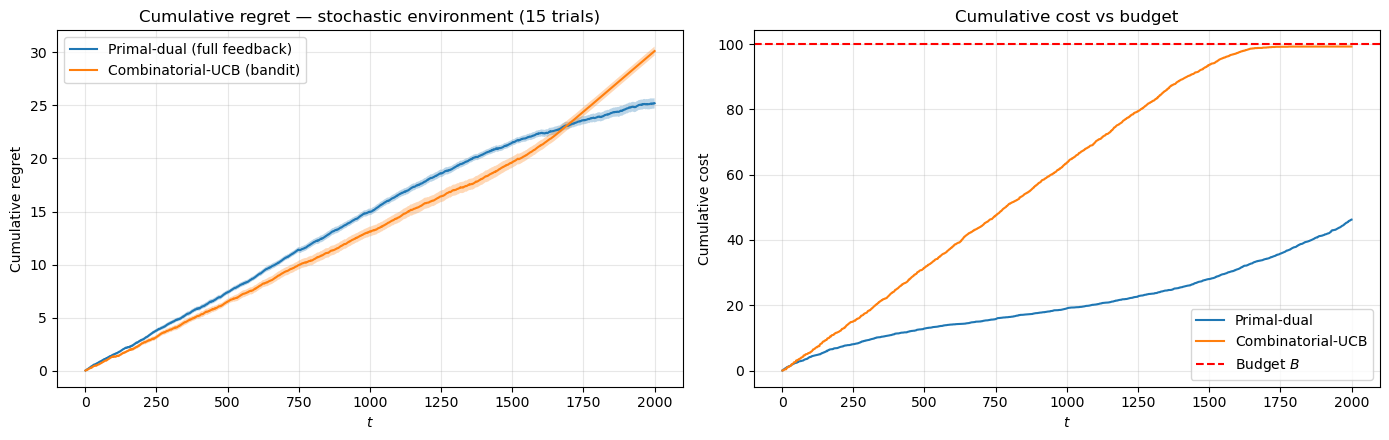

Stochastic env — final average regret: PD = 25.20, C-UCB = 30.12
Stochastic env — final average cost:   PD = 46.25, C-UCB = 99.29  (B = 100)


In [9]:
# ============================================================
# Experiment 1: stochastic environment
# ============================================================
n_trials = 15

pd_regret_stoch = []
pd_cost_stoch = []
ucb_regret_stoch = []
ucb_cost_stoch = []

for trial in range(n_trials):
    m_trial = stochastic_competing_bids(seed=trial, n_competitors=n_competitors, T=T)
    np.random.seed(trial)      # reproducible algorithm randomness (as in Exp. 2)

    # --- primal-dual (full feedback) ---
    pd = PrimalDualAgent(super_arms, empty_idx, T, B, F_max, C_max)
    u_pd = np.zeros(T)
    c_pd = np.zeros(T)
    for t in range(T):
        a = pd.pull_arm()
        f_vec, c_vec = super_arm_fc(m_trial[:, t], super_arms, my_valuations,
                                    available_bids, bid_to_index)
        pd.update(f_vec, c_vec, a)
        u_pd[t] = f_vec[a]
        c_pd[t] = c_vec[a]
    pd_regret_stoch.append(np.cumsum(OPT_S - u_pd))
    pd_cost_stoch.append(np.cumsum(c_pd))

    # --- combinatorial-UCB (bandit feedback) ---
    ucba = CombinatorialUCBAgent(super_arms, empty_idx, bid_to_index,
                                 n_campaigns, n_bids, my_valuations, T, B)
    u_ucb = np.zeros(T)
    c_ucb = np.zeros(T)
    for t in range(T):
        a = ucba.pull_arm()
        S, bids = super_arms[a]
        if S:
            win = available_bids[None, :] >= m_trial[:, t, None]          # (N, Kb)
            rew_t = (my_valuations[:, None] - available_bids[None, :]) * win
            cost_t = available_bids[None, :] * win
            f_list = [rew_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
            c_list = [cost_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
        else:
            f_list, c_list = [], []
        ucba.update(S, bids, f_list, c_list)
        u_ucb[t] = sum(f_list)
        c_ucb[t] = sum(c_list)
    ucb_regret_stoch.append(np.cumsum(OPT_S - u_ucb))
    ucb_cost_stoch.append(np.cumsum(c_ucb))

pd_regret_stoch = np.array(pd_regret_stoch)
pd_cost_stoch = np.array(pd_cost_stoch)
ucb_regret_stoch = np.array(ucb_regret_stoch)
ucb_cost_stoch = np.array(ucb_cost_stoch)

rounds = np.arange(1, T + 1)

def plot_curves(regret_pd, regret_ucb, cost_pd, cost_ucb, title, n_tr):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    ax1.plot(rounds, regret_pd.mean(axis=0), label="Primal-dual (full feedback)")
    ax1.fill_between(rounds,
                     regret_pd.mean(axis=0) - regret_pd.std(axis=0) / np.sqrt(n_tr),
                     regret_pd.mean(axis=0) + regret_pd.std(axis=0) / np.sqrt(n_tr),
                     alpha=0.3)
    ax1.plot(rounds, regret_ucb.mean(axis=0), label="Combinatorial-UCB (bandit)")
    ax1.fill_between(rounds,
                     regret_ucb.mean(axis=0) - regret_ucb.std(axis=0) / np.sqrt(n_tr),
                     regret_ucb.mean(axis=0) + regret_ucb.std(axis=0) / np.sqrt(n_tr),
                     alpha=0.3)
    ax1.set_xlabel("$t$"); ax1.set_ylabel("Cumulative regret")
    ax1.set_title(title); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(rounds, cost_pd.mean(axis=0), label="Primal-dual")
    ax2.plot(rounds, cost_ucb.mean(axis=0), label="Combinatorial-UCB")
    ax2.axhline(B, color="red", ls="--", label="Budget $B$")
    ax2.set_xlabel("$t$"); ax2.set_ylabel("Cumulative cost")
    ax2.set_title("Cumulative cost vs budget"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_curves(pd_regret_stoch, ucb_regret_stoch, pd_cost_stoch, ucb_cost_stoch,
            f"Cumulative regret — stochastic environment ({n_trials} trials)", n_trials)

print(f"Stochastic env — final average regret: PD = {pd_regret_stoch.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_regret_stoch.mean(axis=0)[-1]:.2f}")
print(f"Stochastic env — final average cost:   PD = {pd_cost_stoch.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_cost_stoch.mean(axis=0)[-1]:.2f}  (B = {B})")

## Experiment 2 — highly non-stationary environment

We use the **same** fixed sequence $m_1,\dots,m_T$ (oblivious adversary) for all trials; only the algorithms' internal randomness changes. The baseline is the in-hindsight LP $OPT_A$; because the environment is adversarial, the per-round benchmark is $\rho\,OPT_A$. Following Lab 10, we also inspect the behaviour *inside* each segment (average utility per segment and budget depletion), to see how the two agents react to each abrupt change.

OPT_A (per-round, in hindsight): 0.09102242152466443
Per-round benchmark rho*OPT_A:   0.004551121076233222


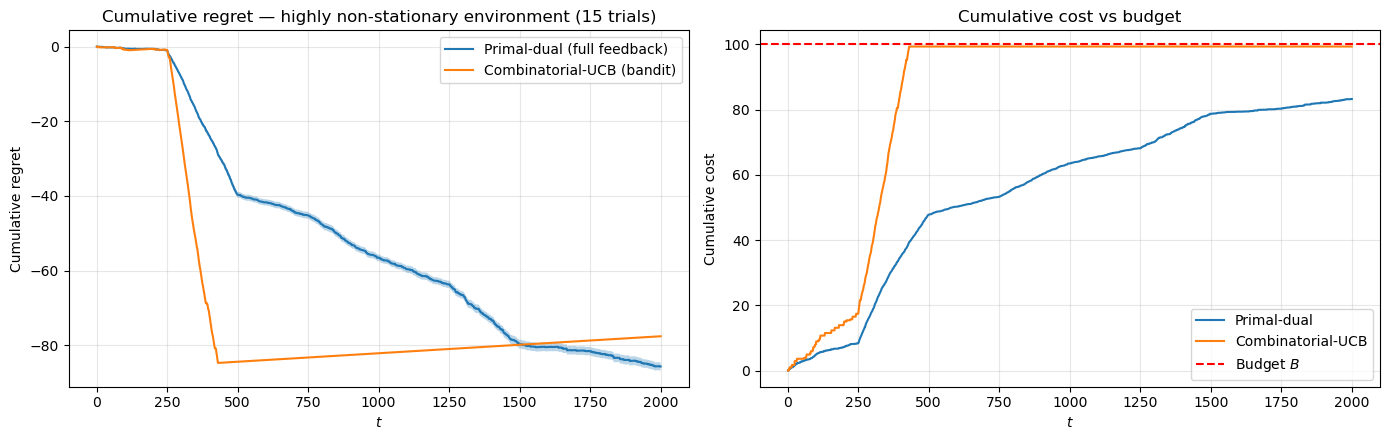

Non-stationary env — final average regret: PD = -85.68, C-UCB = -77.60
Non-stationary env — final average cost:   PD = 83.21, C-UCB = 99.30  (B = 100)


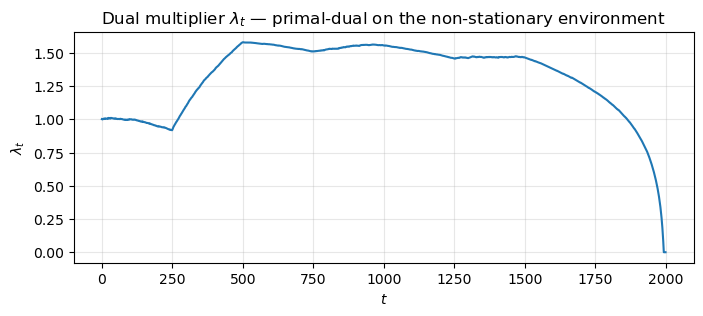

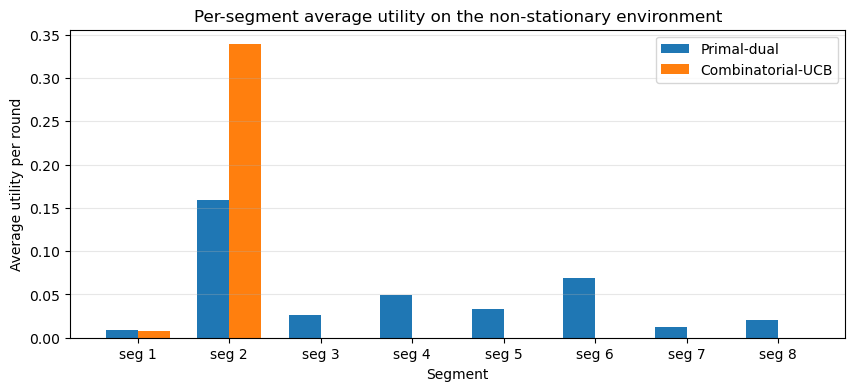

Budget depletion round per trial (None = budget never exhausted):
  PD:    [None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
  C-UCB: [431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431]


In [10]:
# ============================================================
# Experiment 2: highly non-stationary environment
# ============================================================
m_ns = nonstationary_competing_bids(seed=123, n_competitors=n_competitors,
                                    T=T, segment_scales=segment_scales)

gamma_a, OPT_A = adversarial_clairvoyant(m_ns, super_arms, my_valuations,
                                         available_bids, bid_to_index, rho)
benchmark_A = rho * OPT_A
print("OPT_A (per-round, in hindsight):", OPT_A)
print("Per-round benchmark rho*OPT_A:  ", benchmark_A)

n_trials_ns = 15

pd_regret_ns = []
pd_cost_ns = []
ucb_regret_ns = []
ucb_cost_ns = []
pd_utils_ns = []
ucb_utils_ns = []
pd_last = None

for trial in range(n_trials_ns):
    np.random.seed(1000 + trial)          # same m sequence, different algorithm randomness

    # --- primal-dual (full feedback) ---
    pd = PrimalDualAgent(super_arms, empty_idx, T, B, F_max, C_max)
    u_pd = np.zeros(T)
    c_pd = np.zeros(T)
    for t in range(T):
        a = pd.pull_arm()
        f_vec, c_vec = super_arm_fc(m_ns[:, t], super_arms, my_valuations,
                                    available_bids, bid_to_index)
        pd.update(f_vec, c_vec, a)
        u_pd[t] = f_vec[a]
        c_pd[t] = c_vec[a]
    pd_regret_ns.append(np.cumsum(benchmark_A - u_pd))
    pd_cost_ns.append(np.cumsum(c_pd))
    pd_utils_ns.append(u_pd)
    pd_last = pd

    # --- combinatorial-UCB (bandit feedback) ---
    np.random.seed(1000 + trial)
    ucba = CombinatorialUCBAgent(super_arms, empty_idx, bid_to_index,
                                 n_campaigns, n_bids, my_valuations, T, B)
    u_ucb = np.zeros(T)
    c_ucb = np.zeros(T)
    for t in range(T):
        a = ucba.pull_arm()
        S, bids = super_arms[a]
        if S:
            win = available_bids[None, :] >= m_ns[:, t, None]
            rew_t = (my_valuations[:, None] - available_bids[None, :]) * win
            cost_t = available_bids[None, :] * win
            f_list = [rew_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
            c_list = [cost_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
        else:
            f_list, c_list = [], []
        ucba.update(S, bids, f_list, c_list)
        u_ucb[t] = sum(f_list)
        c_ucb[t] = sum(c_list)
    ucb_regret_ns.append(np.cumsum(benchmark_A - u_ucb))
    ucb_cost_ns.append(np.cumsum(c_ucb))
    ucb_utils_ns.append(u_ucb)

pd_regret_ns = np.array(pd_regret_ns)
pd_cost_ns = np.array(pd_cost_ns)
ucb_regret_ns = np.array(ucb_regret_ns)
ucb_cost_ns = np.array(ucb_cost_ns)
pd_utils_ns = np.array(pd_utils_ns)
ucb_utils_ns = np.array(ucb_utils_ns)

plot_curves(pd_regret_ns, ucb_regret_ns, pd_cost_ns, ucb_cost_ns,
            f"Cumulative regret — highly non-stationary environment ({n_trials_ns} trials)", n_trials_ns)

print(f"Non-stationary env — final average regret: PD = {pd_regret_ns.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_regret_ns.mean(axis=0)[-1]:.2f}")
print(f"Non-stationary env — final average cost:   PD = {pd_cost_ns.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_cost_ns.mean(axis=0)[-1]:.2f}  (B = {B})")

# lambda trajectory of the last primal-dual trial
plt.figure(figsize=(8, 3))
plt.plot(pd_last.lmbd_history)
plt.xlabel("$t$"); plt.ylabel("$\\lambda_t$")
plt.title("Dual multiplier $\\lambda_t$ — primal-dual on the non-stationary environment")
plt.grid(alpha=0.3); plt.show()

# --- Per-segment analysis: who keeps earning after every change? ---
# Following Lab 10, we look at the behaviour *inside* each segment instead of
# only at the final numbers.
seg_len = T // n_segments
pd_seg = pd_utils_ns.reshape(n_trials_ns, n_segments, seg_len).mean(axis=(0, 2))
ucb_seg = ucb_utils_ns.reshape(n_trials_ns, n_segments, seg_len).mean(axis=(0, 2))

x = np.arange(n_segments)
width = 0.35
plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, pd_seg, width, label="Primal-dual")
plt.bar(x + width / 2, ucb_seg, width, label="Combinatorial-UCB")
plt.xticks(x, [f"seg {s + 1}" for s in x])
plt.xlabel("Segment")
plt.ylabel("Average utility per round")
plt.title("Per-segment average utility on the non-stationary environment")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()

def depletion_round(cum_cost, B):
    """First round in which the budget is (almost) exhausted; None if never."""
    idx = np.argwhere(cum_cost >= B - 1)
    return idx[0, 0] + 1 if idx.size else None

# NOTE: pd_cost_ns / ucb_cost_ns already contain CUMULATIVE costs
pd_dep = [depletion_round(cum, B) for cum in pd_cost_ns]
ucb_dep = [depletion_round(cum, B) for cum in ucb_cost_ns]
print("Budget depletion round per trial (None = budget never exhausted):")
print("  PD:   ", pd_dep)
print("  C-UCB:", ucb_dep)

## Best-of-both-worlds summary

The key claim of Requirement 3 is that **one** primal-dual algorithm (same hyperparameters, no tuning per environment) behaves well in **both** environments:

- **Stochastic**: sublinear regret against the true LP clairvoyant $OPT_S$ ($R_T \approx 25 \ll T = 2000$, with shrinking increments).
- **Highly non-stationary / adversarial**: the algorithm exceeds the worst-case benchmark $\rho\,OPT_A$ (no algorithm can *guarantee* more than a $\rho$ fraction of $OPT_A$ in the worst case).

The comparison with Combinatorial-UCB highlights why the primal-dual method is the right tool for the "best of both worlds" claim: C-UCB (bandit feedback) is competitive on the stochastic environment, but on the non-stationary one it is outperformed by the primal-dual method, since its UCB averages become stale after the environment changes.

### How to read the numbers

- **Negative "regret" in the non-stationary table is not an error.** The benchmark is the *worst-case* guarantee $\rho\,OPT_A$ (here $0.05 \times OPT_A$). On this particular sequence both agents do better than that guarantee, so the regret is negative. It does **not** mean we beat the in-hindsight optimum $OPT_A$ itself (PD total utility $\approx 95$ vs $OPT_A \cdot T \approx 182$).
- **The primal-dual method spends less than the budget in the stochastic case** ($\approx 45/100$ vs C-UCB's $\approx 99/100$) while still achieving lower regret and higher utility. This is an interesting (and explainable) result: the dual multiplier makes the agent conservative, and the marginal utility of the last units of budget is small. It is a budget *cap*, not a spending target.
- **The comparison is not apples-to-apples in feedback**: the primal-dual agent uses full feedback (allowed by Requirement 3), while C-UCB uses bandit feedback (as in Requirement 2). This is intentional, but should be stated in the presentation.
- **PD keeps the budget alive; C-UCB front-loads it (per-segment plot).** C-UCB earns most of its utility in the first cheap segments and then idles, because its optimistic cost estimates make it burn the budget early; PD's dual multiplier continuously reprices the budget, so it smooths spending across segments and keeps earning after every distribution change. This is the practical, Lab-10-style reason why a full-feedback primal-dual learner is more robust to non-stationarity than an optimistic bandit learner: it adapts to the *current* round instead of relying on stale averages.

In [11]:
# ============================================================
# Cross-table
# ============================================================
print("=" * 64)
print("Final average cumulative regret")
print("=" * 64)
print(f"{'Environment':<26}{'Primal-dual':>14}{'C-UCB':>14}")
print("-" * 64)
print(f"{'Stochastic':<26}{pd_regret_stoch.mean(axis=0)[-1]:>14.2f}{ucb_regret_stoch.mean(axis=0)[-1]:>14.2f}")
print(f"{'Highly non-stationary':<26}{pd_regret_ns.mean(axis=0)[-1]:>14.2f}{ucb_regret_ns.mean(axis=0)[-1]:>14.2f}")
print()
print("Final average cumulative cost (budget B = {})".format(B))
print(f"{'Environment':<26}{'Primal-dual':>14}{'C-UCB':>14}")
print("-" * 64)
print(f"{'Stochastic':<26}{pd_cost_stoch.mean(axis=0)[-1]:>14.2f}{ucb_cost_stoch.mean(axis=0)[-1]:>14.2f}")
print(f"{'Highly non-stationary':<26}{pd_cost_ns.mean(axis=0)[-1]:>14.2f}{ucb_cost_ns.mean(axis=0)[-1]:>14.2f}")
print()
print("Final average total utility (over T rounds)")
print(f"{'Environment':<26}{'Primal-dual':>14}{'C-UCB':>14}")
print("-" * 64)
opt_total_s = OPT_S * T
bench_total_a = benchmark_A * T
print(f"{'Stochastic':<26}{opt_total_s - pd_regret_stoch.mean(axis=0)[-1]:>14.2f}{opt_total_s - ucb_regret_stoch.mean(axis=0)[-1]:>14.2f}")
print(f"{'Highly non-stationary':<26}{bench_total_a - pd_regret_ns.mean(axis=0)[-1]:>14.2f}{bench_total_a - ucb_regret_ns.mean(axis=0)[-1]:>14.2f}")

Final average cumulative regret
Environment                  Primal-dual         C-UCB
----------------------------------------------------------------
Stochastic                         25.20         30.12
Highly non-stationary             -85.68        -77.60

Final average cumulative cost (budget B = 100)
Environment                  Primal-dual         C-UCB
----------------------------------------------------------------
Stochastic                         46.25         99.29
Highly non-stationary              83.21         99.30

Final average total utility (over T rounds)
Environment                  Primal-dual         C-UCB
----------------------------------------------------------------
Stochastic                         20.69         15.77
Highly non-stationary              94.79         86.70
